In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from dash import Dash, html, dcc, dash_table

In [2]:
heart_disease_df = pd.read_csv('Heart_Disease_Dataset - 3000_Records_in_2025/heart_disease_dataset.csv')
heart_disease_df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,smoking,diabetes,bmi,heart_disease
0,67,1,2,111,536,0,2,88,0,1.3,3,2,3,1,0,23.4,0
1,57,1,3,109,107,0,2,119,0,5.4,2,0,3,0,1,35.4,0
2,43,1,4,171,508,0,1,113,0,3.7,3,0,7,1,1,29.9,0
3,71,0,4,90,523,0,2,152,0,4.7,2,1,3,1,0,15.2,1
4,36,1,2,119,131,0,2,128,0,5.9,3,1,3,1,0,16.7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3064,52,0,1,169,479,0,0,124,0,3.7,2,3,3,0,0,27.8,0
3065,75,0,4,90,372,0,2,141,0,2.1,2,2,3,0,1,37.0,1
3066,68,1,4,166,564,0,1,76,0,4.5,3,1,3,0,0,16.1,0
3067,66,0,3,143,113,1,1,207,0,3.6,1,0,6,0,0,27.7,0


In [3]:
type(heart_disease_df)

pandas.core.frame.DataFrame

In [4]:
heart_disease_df.dtypes

age                int64
sex                int64
cp                 int64
trestbps           int64
chol               int64
fbs                int64
restecg            int64
thalach            int64
exang              int64
oldpeak          float64
slope              int64
ca                 int64
thal               int64
smoking            int64
diabetes           int64
bmi              float64
heart_disease      int64
dtype: object

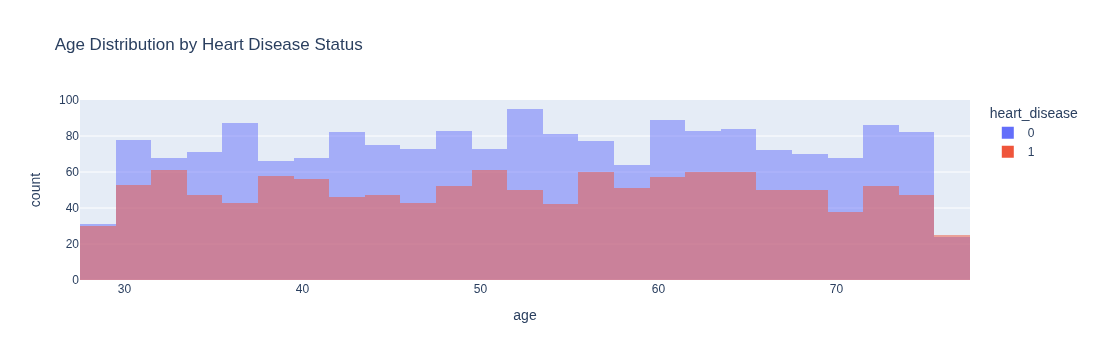

In [3]:
# Visualizations

# Figure 1
fig1 = px.pie(
    heart_disease_df, 
    names='heart_disease', 
    title='Heart Disease Prevalence',
    color='heart_disease',
    color_discrete_map={0: 'lightblue', 1: 'red'},
    hole=0.3
)

# Figure 2
fig2 = px.histogram(
    heart_disease_df, 
    x='age', 
    color='heart_disease',
    barmode='overlay',
    nbins=30,
    title='Age Distribution by Heart Disease Status'
)

# Figure 3
sex_map = {0: 'Female', 1: 'Male'}
heart_disease_df['sex_str'] = heart_disease_df['sex'].map(sex_map)

fig3 = px.bar(
    heart_disease_df.groupby(['sex_str', 'heart_disease']).size().reset_index(name='count'),
    x='sex_str', y='count', color='heart_disease', barmode='group',
    title='Heart Disease by Sex'
)

# Figure 4
fig4 = px.box(
    heart_disease_df, 
    x='heart_disease', 
    y='bmi',
    points='all',
    title='BMI Distribution by Heart Disease Status'
)

# Figure 5
numeric_df = heart_disease_df.select_dtypes(include=np.number)
corr = numeric_df.corr()

fig5 = px.imshow(
    corr, 
    text_auto=True, 
    aspect="auto",
    title='Feature Correlation Heatmap'
)

# Figure 6
fig6 = px.histogram(
    heart_disease_df, 
    x='cp', color='heart_disease', 
    barmode='stack',
    category_orders={'cp': sorted(heart_disease_df['cp'].unique())},
    title='Chest Pain Type by Heart Disease Status'
)

# Figure 7
fig7 = px.scatter(
    heart_disease_df,
    x='age', y='bmi',
    color='heart_disease',
    title='Age vs BMI (Heart Disease Coloring)'
)

# Figure 8
fig8 = px.bar(
    heart_disease_df.groupby(['diabetes', 'heart_disease']).size().reset_index(name='count'),
    x='diabetes', y='count', color='heart_disease', barmode='group',
    title='Diabetes Prevalence by Heart Disease Status'
)


fig2

In [34]:
import dash
from dash import html, dcc

app = dash.Dash(__name__)

sidebar_style = {
    'position': 'fixed',
    'top': '0',
    'left': '0',
    'bottom': '0',
    'width': '280px',
    'background-color': 'rgba(180, 200, 220, 0.2)',
    'padding': '20px 10px',
    'boxShadow': '2px 0px 6px rgba(0,0,0,0.07)',
    'font-family':'candara',
    'zIndex': 1000,
    'font-size':'20px'
}

content_style = {
    'marginLeft': '300px',  # make space for sidebar
    'padding': '0px 0px'
}

app.layout = html.Div(children=[
    # Sidebar
    html.Div([
        html.H3('Sidebar', style={'marginBottom': '20px'}),
        html.Div(children = [
            html.Div([
                        html.Label("Age Range:", style={'font-weight': 'bold'}),
                        html.Br(),
                        dcc.RangeSlider(
                            id='age-slider',
                            min=heart_disease_df['age'].min(),
                            max=heart_disease_df['age'].max(),
                            value=[heart_disease_df['age'].min(), heart_disease_df['age'].max()],
                            marks={i: str(i) for i in range(30, 81, 10)}
                        ),
                        html.Br(),
                        html.Br(),
                        html.Label("Select the sex", style={'font-weight': 'bold'}),
                        dcc.Dropdown(
                                    options=[
                                        {"label": "Male", "value": 1},
                                        {"label": "Female", "value": 0}
                                    ],
                                    value=1,  # default = Smokes
                                    id="sex-dropdown"
                                ),
                        html.Br(),
                        html.Br(),
                        html.Label("Smoking status", style={'font-weight': 'bold'}),
                        dcc.Dropdown(
                                    options=[
                                        {"label": "Smokes", "value": 1},
                                        {"label": "Doesnt Smoke", "value": 0}
                                    ],
                                    value=1,  # default = Smokes
                                    id="smoking-dropdown"
                                ),
                        html.Br(),
                        html.Br(),
                        html.Label("Diabetes Status", style={'font-weight': 'bold'}),
                        dcc.Dropdown(
                                    options=[
                                        {"label": "Diabetes", "value": 1},
                                        {"label": "No diabetes", "value": 0}
                                    ],
                                    value=1,  # default = Smokes
                                    id="diabetes-dropdown"
                                ),
                        html.Br(),
                        html.Br(),
                        html.Button("Apply", id="apply-button", n_clicks=0, style={'width':'76px','height':'50px','margin-right':'100px'}),
                        html.Button("Reset", id="reset-button", n_clicks=0, style={'width':'76px','height':'50px'})
                        
                        
                    ]),
            

        ],),
    ], style=sidebar_style),

    # Main Content (with margin applied)
    html.Div(children=[
        # CSS Styles
        dcc.Markdown('''
        <style>
            @media (max-width: 768px) {
                #row_2_column_1, #row_2_column_2 {
                    display: block !important;
                    width: 100% !important;
                    margin-right: 0 !important;
                    height: auto !important;
                }
            }
        </style>
        ''', dangerously_allow_html=True),
        # Row 1
        html.Div(id="row_1", children=[
            html.H2(children='Heart Disease Analytics', style={'text-align':'left',
                                                               'font-size':'30px',
                                                               'font-family':'candara',
                                                               'margin-top':'0',
                                                               'position':'absolute',
                                                               'marginTop':'15px',
                                                               'marginLeft':'40px'})
        ], style={'width':'100%',
                  'height':'70px',
                  'box-shadow':'hsl(0, 0%, 80%) 0 0 6px',
                  'background-color':'white',
                  'position':'relative'}),

        # Row 2
        html.Div(id="row_2", children=[
            html.Div(id="row_2_column_1", children=[
                dcc.Graph(
                    id = "figure_2",
                    figure = fig2
                ),
            ], style={
                'width':'49.5%',
                'height':'400px',
                'background-color':'white', 
                'display':'inline-block',
                'vertical-align':'top',
                'marginRight':'0.5%',
                'box-shadow':'hsl(0, 0%, 80%) 0 0 6px'
            }),
            html.Div(id="row_2_column_2", children=[
                dcc.Graph(
                    id = "figure_1",
                    figure = fig1
                ),
            ], style={
                'width':'50%',
                'height':'400px',
                'background-color':'white', 
                'display':'inline-block',
                'vertical-align':'top',
                'box-shadow':'hsl(0, 0%, 80%) 0 0 6px'
            }),
        ], style={'width':'100%','height':'auto', 'marginTop':'10px'}),

        # Row 3
        html.Div(id="row_3", children=[
            html.Div(id="row_3_column_1", children=[
                dcc.Graph(
                    id = "figure_3",
                    figure = fig3
                ),
            ], style={
                'width':'49.5%',
                'height':'400px',
                'background-color':'white', 
                'display':'inline-block',
                'vertical-align':'top',
                'marginRight':'0.5%',
                'box-shadow':'hsl(0, 0%, 80%) 0 0 6px'
            }),
            html.Div(id="row_3_column_2", children=[
                dcc.Graph(
                    id = "figure_6",
                    figure = fig6
                ),
            ], style={
                'width':'50%',
                'height':'400px',
                'background-color':'white', 
                'display':'inline-block',
                'vertical-align':'top',
                'box-shadow':'hsl(0, 0%, 80%) 0 0 6px'
            }),
        ], style={'width':'100%','height':'410px', 'marginTop':'10px'}),
    ], style=content_style)  # <--- MARGIN ADDED HERE
], style = {'background-color':'#e9ecef'})

if __name__ == "__main__":
    app.run(debug=True)